# **Multi-task learning**

As per Category 2, AI was used to proofread code

## 1. Setup


In [1]:
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
import json, math, time
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import mean_absolute_error
from tqdm.auto import tqdm

# baseline pipeline
from mmac_utils import *
from mmac_utils import _SCALAR_METRICS, _json_default

MTL_OUTPUT_DIR: Path = OUTPUT_DIR / "mtl"
MTL_ARTEFACT_DIR: Path = ARTEFACT_DIR / "mtl"
for d in (MTL_OUTPUT_DIR, MTL_ARTEFACT_DIR): d.mkdir(parents=True, exist_ok=True)
NUM_CENTERS: int = 2

device = get_device()
print(f"device = {device}, baseline ckpt exists = {BASELINE_CKPT.is_file()}")


device = cpu, baseline ckpt exists = False


/home/sami/Documents/UCL/MPHY0050/AppliedAIGroupProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Configuration


In [ ]:
@dataclass
class MTLConfig:
    seed: int = 42 # same as baseline so the split lines up
    image_size: int = 224 # ResNet-50 canonical input
    val_split: float = 0.15 # matches baseline 85/15 stratified split
    num_workers: int = 4
    batch_size: int = 64 
    dropout: float = 0.3
    use_age: bool = True
    use_sex: bool = True
    use_center: bool = True
    weighting: str = "fixed"
    w_grade: float = 1.0 # primary task stays at weight 1
    w_age: float = 0.2 # age is noisy but cheap, low weight
    w_sex: float = 0.1 # most-missing field, lowest weight
    w_center: float = 0.2 # site signal, same as age
    epochs: int = 20 # shorter than baseline (30) - MTL step is heavier
    head_lr: float = 1e-3 # newly-initialised heads
    backbone_lr: float = 1e-4 # fine-tune pretrained backbone slower
    weight_decay: float = 1e-4
    warmup_epochs: int = 1 # linear warmup then cosine decay
    grad_clip: float = 1.0
    use_amp: bool = True # mixed precision on CUDA
    early_stop_patience: int = 7 # epochs without val-kappa improvement
    primary_metric: str = "quadratic_kappa" # ordinal metric
    experiment_name: str = "mtl_fixed"

    def as_dict(self) -> Dict[str, Any]:
        return {k: (str(v) if isinstance(v, Path) else v) for k, v in self.__dict__.items()}

TRAIN: bool = False # False to load checkpoints instead of retrain
RELOAD_ONLY: bool = True # set True to skip inference

## 3. Data pipeline - aux targets with masks

Extend the baseline dataset so each row also carries `(age_std, sex_bin, center_idx)`
plus a `*_mask` for missing values. Only `sex` actually has missing rows in practice,
but masking keeps all three robust. Age is standardised using training-split stats only.


In [ ]:
@dataclass
class AuxEncoders:
    """train-split fitted encoders: standardise age, map sex + data_center."""
    age_mean: float
    age_std: float
    sex_map: Dict[str, int] = field(default_factory=lambda: {"male": 0, "female": 1})
    center_map: Dict[int, int] = field(default_factory=lambda: {1: 0, 2: 1})

    @classmethod
    def fit(cls, frame: pd.DataFrame) -> "AuxEncoders":
        # fit only on train rows so val/test stay untouched
        ages = frame["age"].dropna().astype(float).to_numpy()
        mean = float(ages.mean()) if ages.size else 0.0
        std = float(ages.std(ddof=0)) if ages.size else 1.0
        return cls(age_mean=mean, age_std=std if std > 1e-6 else 1.0) # guard zero std

    def encode(self, row: pd.Series) -> Dict[str, Any]:
        a = row.get("age")
        if a is None or (isinstance(a, float) and np.isnan(a)):
            age_v, age_m = 0.0, 0.0 # value ignored by mask
        else:
            age_v, age_m = (float(a) - self.age_mean) / self.age_std, 1.0
        s = row.get("sex")
        sex_v, sex_m = (self.sex_map[s], 1.0) if isinstance(s, str) and s in self.sex_map else (0, 0.0)
        c = row.get("data_center")
        if c is None or (isinstance(c, float) and np.isnan(c)):
            c_v, c_m = 0, 0.0
        else:
            idx = self.center_map.get(int(c), -1)
            c_v, c_m = (idx, 1.0) if idx >= 0 else (0, 0.0) # unseen id -> treat as missing
        return {"age": age_v, "age_mask": age_m,
                "sex": int(sex_v), "sex_mask": sex_m,
                "center": int(c_v), "center_mask": c_m}


@dataclass
class MMACMTLDataset(Dataset):
    """returns (image, target_dict) with grade + aux targets + masks."""
    frame: pd.DataFrame
    image_dir: Path
    encoders: AuxEncoders
    transform: Optional[transforms.Compose] = None

    def __post_init__(self) -> None:
        self.frame = self.frame.reset_index(drop=True)
        self.image_dir = Path(self.image_dir)

    def __len__(self) -> int: return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        img = Image.open(self.image_dir / row[IMAGE_COL]).convert("RGB")
        if self.transform is not None: img = self.transform(img)
        aux = self.encoders.encode(row) # dict of values + masks
        target = {
            "grade":       torch.tensor(int(row[LABEL_COL]), dtype=torch.long),
            "age":         torch.tensor(aux["age"], dtype=torch.float32),
            "age_mask":    torch.tensor(aux["age_mask"], dtype=torch.float32),
            "sex":         torch.tensor(aux["sex"], dtype=torch.long),
            "sex_mask":    torch.tensor(aux["sex_mask"], dtype=torch.float32),
            "center":      torch.tensor(aux["center"], dtype=torch.long),
            "center_mask": torch.tensor(aux["center_mask"], dtype=torch.float32),
        }
        return img, target


def build_mtl_dataloaders(cfg: MTLConfig) -> Dict[str, Any]:
    tr_frame = load_label_frame(TRAIN_CSV, TRAIN_DIR)
    te_frame = load_label_frame(TEST_CSV, TEST_DIR)

    tr_frame, va_frame = stratified_split(tr_frame, cfg.val_split, cfg.seed)
    encoders = AuxEncoders.fit(tr_frame) # fit only on training rows
    print(f"[data] age mean={encoders.age_mean:.2f} std={encoders.age_std:.2f}")

    # train gets augmentations, val / test just resize + normalise
    tr_tfm, ev_tfm = build_train_transform(cfg.image_size), build_eval_transform(cfg.image_size)
    ds = {
        "train": MMACMTLDataset(tr_frame, TRAIN_DIR, encoders, tr_tfm),
        "val":   MMACMTLDataset(va_frame, TRAIN_DIR, encoders, ev_tfm),
        "test":  MMACMTLDataset(te_frame, TEST_DIR,  encoders, ev_tfm),
    }
    common = dict(batch_size=cfg.batch_size, num_workers=cfg.num_workers,
                  pin_memory=True, persistent_workers=cfg.num_workers > 0)
    return {
        # only train shuffles + drops last
        "train": DataLoader(ds["train"], shuffle=True,  drop_last=True,  **common),
        "val":   DataLoader(ds["val"],   shuffle=False, drop_last=False, **common),
        "test":  DataLoader(ds["test"],  shuffle=False, drop_last=False, **common),
        **{f"{k}_ds": v for k, v in ds.items()}, # expose datasets too for sanity checks
        "encoders": encoders,
    }


## 4. Model - shared backbone, per-task heads

In [ ]:
class MMACMTLResNet50(nn.Module):
    """shared trunk + (grade, age, sex, center) heads on a ResNet-50 backbone."""

    def __init__(self, dropout: float = 0.3, pretrained: bool = True,
                 use_age: bool = True, use_sex: bool = True, use_center: bool = True):
        super().__init__()
        # reuse the baseline model so weights line up for warm-start 
        base = MMACResNet50(num_classes=NUM_CLASSES, pretrained=pretrained, dropout=dropout)
        self.backbone = base.backbone

        self.shared = nn.Sequential(*list(base.head.children())[:4])
        # per-task heads, all read from the same 512-d shared representation
        self.grade_head  = nn.Linear(512, NUM_CLASSES) # primary task
        self.age_head    = nn.Linear(512, 1) if use_age else None # regression
        self.sex_head    = nn.Linear(512, 1) if use_sex else None # binary logit
        self.center_head = nn.Linear(512, NUM_CENTERS) if use_center else None # 2-class CE
        # kaiming init for the new heads
        for h in [self.grade_head, self.age_head, self.sex_head, self.center_head]:
            if h is None: continue
            nn.init.kaiming_normal_(h.weight, nonlinearity="relu")
            nn.init.zeros_(h.bias)

    def forward(self, x) -> Dict[str, torch.Tensor]:

        z = self.shared(self.backbone(x))
        out: Dict[str, torch.Tensor] = {"grade": self.grade_head(z)}

        if self.age_head    is not None: out["age"]    = self.age_head(z).squeeze(-1)
        if self.sex_head    is not None: out["sex"]    = self.sex_head(z).squeeze(-1)
        if self.center_head is not None: out["center"] = self.center_head(z)
        return out

    def parameter_groups(self, backbone_lr, head_lr, weight_decay):
        # split params into two LR groups: slow backbone, faster heads
        head_params: List[torch.nn.Parameter] = list(self.shared.parameters()) + list(self.grade_head.parameters())
        for h in (self.age_head, self.sex_head, self.center_head):
            if h is not None: head_params += list(h.parameters())
        return [
            {"params": list(self.backbone.parameters()), "lr": backbone_lr,
             "weight_decay": weight_decay, "name": "backbone"},
            {"params": head_params, "lr": head_lr,
             "weight_decay": weight_decay, "name": "heads"},
        ]


def warm_start_mtl(model: MMACMTLResNet50, ckpt_path: Path) -> None:
    """copy backbone + shared trunk + grade head from the baseline checkpoint.
    baseline head layout: 0=Linear, 1=BN, 2=ReLU, 3=Dropout, 4=Linear(grade)."""
    p = Path(ckpt_path)
    if not p.is_file():
        print(f"[warm] no baseline ckpt at {p} - skipping"); return
    state = torch.load(p, map_location="cpu")["model_state"]

    bb = {k.removeprefix("backbone."): v for k, v in state.items() if k.startswith("backbone.")}
    model.backbone.load_state_dict(bb, strict=False)

    shared_state, grade_state = {}, {}
    for k, v in state.items():
        if not k.startswith("head."): continue
        _, idx, *rest = k.split(".")
        sub = ".".join(rest)
        if idx in ("0", "1"):
            shared_state[f"{idx}.{sub}"] = v
        elif idx == "4":
            grade_state[sub] = v
    if shared_state: model.shared.load_state_dict(shared_state, strict=True)
    if grade_state:  model.grade_head.load_state_dict(grade_state, strict=True)
    print(f"[warm] loaded backbone + shared + grade_head from {p.name}")


## 5. Multi-task loss

- `fixed`: `L = w_g L_grade + w_a L_age + w_s L_sex + w_c L_center`.
- `uncertainty`: each task has a learnable `log_var`, contributing
  `0.5 * exp(-log_var) * L + 0.5 * log_var`. Noisier tasks self-damp.

Per-sample masking drops missing aux labels so they contribute no gradient noise.


In [ ]:
class MTLLossModule(nn.Module):
    def __init__(self, weighting: str = "fixed",
                 use_age=True, use_sex=True, use_center=True,
                 w_grade=1.0, w_age=0.2, w_sex=0.1, w_center=0.2):
        super().__init__()
        assert weighting in {"fixed", "uncertainty"}
        self.weighting = weighting
        self.active = ["grade"]
        if use_age:    self.active.append("age")
        if use_sex:    self.active.append("sex")
        if use_center: self.active.append("center")
        self.fixed_w = {"grade": w_grade, "age": w_age, "sex": w_sex, "center": w_center}
        self.log_vars = nn.ParameterDict({k: nn.Parameter(torch.zeros(())) for k in self.active})

    @staticmethod
    def _masked_mean(x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        return (x * mask).sum() / mask.sum().clamp(min=1.0)

    def per_task(self, out: Dict[str, torch.Tensor], tgt: Dict[str, torch.Tensor]):
        # grade is never masked - every row has a grade label
        losses = {"grade": F.cross_entropy(out["grade"], tgt["grade"])}
        if "age" in self.active:
            # MSE on standardised age, masked to rows that had a real value
            losses["age"] = self._masked_mean((out["age"] - tgt["age"]) ** 2, tgt["age_mask"])
        if "sex" in self.active:
            # BCE with logits so don't need a sigmoid, reduction="none" gives per-row loss for masking
            per = F.binary_cross_entropy_with_logits(out["sex"], tgt["sex"].float(), reduction="none")
            losses["sex"] = self._masked_mean(per, tgt["sex_mask"])
        if "center" in self.active:
            # 2-class CE, masked by center availability
            per = F.cross_entropy(out["center"], tgt["center"], reduction="none")
            losses["center"] = self._masked_mean(per, tgt["center_mask"])
        return losses

    def forward(self, out, tgt):
        pt = self.per_task(out, tgt) # dict of scalar tensors, one per active task
        if self.weighting == "fixed":
            # plain weighted sum, weights live in self.fixed_w
            total = sum(self.fixed_w[k] * v for k, v in pt.items())
        else:
            # Kendall, Gal, Cipolla 2018: total = sum_k 0.5 * exp(-s_k) * L_k + 0.5 * s_k
            # exp(-s) auto-damps noisy tasks (big s -> small weight), 0.5*s regulariser keeps s from blowing up
            total = sum(0.5 * torch.exp(-self.log_vars[k]) * v + 0.5 * self.log_vars[k]
                        for k, v in pt.items())
        return total, pt

    def current_log_vars(self) -> Dict[str, float]:
        # snapshot the learnt log-vars for logging (eg writing into history json)
        return {k: float(p.detach().cpu()) for k, p in self.log_vars.items()}


## 6. Training engine

In [ ]:
def _to_dev(d: Dict[str, torch.Tensor], device):
    # move a whole target dict to the GPU in one shot
    return {k: v.to(device, non_blocking=True) for k, v in d.items()}


def _build_optim(model, loss_mod: "MTLLossModule", cfg: "MTLConfig"):
    # two LR groups from the model (backbone vs heads), optionally plus a third for learnable log_vars
    groups = unwrap_model(model).parameter_groups(cfg.backbone_lr, cfg.head_lr, cfg.weight_decay)
    if cfg.weighting == "uncertainty":
        # log_vars get their own group, no weight decay (they're a regularisation knob, not a feature weight)
        groups.append({"params": list(loss_mod.log_vars.parameters()),
                       "lr": cfg.head_lr, "weight_decay": 0.0, "name": "log_vars"})
    return torch.optim.AdamW(groups)


def _run_epoch(model, loader, loss_mod, device, *, optimizer=None,
               grad_clip=0.0, use_amp=False, desc="eval"):
    """one pass over `loader`. if `optimizer` is given we train, else we eval."""
    training = optimizer is not None
    model.train(training); loss_mod.train(training)
    scaler = amp_scaler(use_amp, device) if training else None

    # accumulators for the epoch-level stats we care about
    running = 0.0; seen = 0
    per_task_sum = defaultdict(float) # weighted sum of each per-task loss
    ys, ps, prs = [], [], []
    aux_arr = {k: defaultdict(list) for k in ("age", "sex", "center")}

    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    with (torch.enable_grad() if training else torch.no_grad()):
        for x, target in pbar:
            x = x.to(device, non_blocking=True); target = _to_dev(target, device)
            if training: optimizer.zero_grad(set_to_none=True) # set_to_none is cheaper than zero_
            # autocast wraps forward + loss in fp16 if use_amp, else passthrough
            with amp_ctx(use_amp, device):
                out = model(x)
                total, pt = loss_mod(out, target) # total is the scalar we backprop
            if training:
                # AMP dance: scale loss -> backward -> unscale for clipping -> step -> update scaler
                if scaler is not None:
                    scaler.scale(total).backward()
                    if grad_clip > 0:
                        scaler.unscale_(optimizer) # unscale before clipping so the norm is correct
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    scaler.step(optimizer); scaler.update()
                else:
                    # plain fp32 path (MPS / CPU)
                    total.backward()
                    if grad_clip > 0: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    optimizer.step()

            # sample-weighted accumulators (seen = total samples processed so far)
            bs = x.size(0); seen += bs
            running += float(total.detach()) * bs
            for k, v in pt.items(): per_task_sum[k] += float(v.detach()) * bs

            # stash grade preds + probs for metric computation at epoch end
            with torch.no_grad():
                probs = torch.softmax(out["grade"], dim=1).float().cpu().numpy()
            ys.append(target["grade"].detach().cpu().numpy())
            ps.append(probs.argmax(axis=1)); prs.append(probs)

            # only gather aux preds during eval, and only for heads that exist in this run
            if not training:
                for k in ("age", "sex", "center"):
                    if k not in out: continue
                    # discretise each aux head differently: regression stays continuous,
                    # sex uses sigmoid>0.5, center uses argmax
                    if k == "sex":
                        pred = (torch.sigmoid(out[k]) >= 0.5).long().cpu().numpy()
                    elif k == "center":
                        pred = out[k].argmax(dim=1).cpu().numpy()
                    else:
                        pred = out[k].cpu().numpy()
                    aux_arr[k]["true"].append(target[k].cpu().numpy())
                    aux_arr[k]["pred"].append(pred)
                    aux_arr[k]["mask"].append(target[f"{k}_mask"].cpu().numpy())

            pbar.set_postfix(loss=f"{running / max(seen,1):.4f}")

    # stitch batch arrays into one long array, build the metric bundle from grade preds
    y_true = np.concatenate(ys) if ys else np.array([], dtype=int)
    y_pred = np.concatenate(ps) if ps else np.array([], dtype=int)
    y_prob = np.concatenate(prs) if prs else None
    bundle = compute_metrics(y_true, y_pred, y_prob)
    pt_avg = {k: v / max(seen, 1) for k, v in per_task_sum.items()} # per-task mean loss for logging
    # only keep aux tasks that actually saw a label this epoch (avoids empty arrays)
    aux = {k: {m: np.concatenate(a) for m, a in v.items()} for k, v in aux_arr.items() if v["true"]}
    return running / max(seen, 1), bundle, pt_avg, y_true, y_pred, y_prob, aux


@dataclass
class MTLResult:
    history: TrainingHistory
    best_epoch: int
    best_metric: float
    best_ckpt: Path


def train_mtl(model, loaders, cfg: "MTLConfig", device) -> MTLResult:
    model.to(device)
    # build the loss module fresh - it holds log_vars which need to match the active heads of this cfg
    loss_mod = MTLLossModule(cfg.weighting, cfg.use_age, cfg.use_sex, cfg.use_center,
                             cfg.w_grade, cfg.w_age, cfg.w_sex, cfg.w_center).to(device)
    optimizer = _build_optim(model, loss_mod, cfg)
    scheduler = build_cosine_with_warmup(optimizer, cfg.epochs, cfg.warmup_epochs)
    history = TrainingHistory()
    # early stopping state: track best val metric, stop after `patience` epochs without improvement
    best_metric, best_epoch, patience = -math.inf, -1, cfg.early_stop_patience
    use_amp = cfg.use_amp and device.type == "cuda" # AMP is cuda-only in this project
    best_ckpt = CHECKPOINT_DIR / f"{cfg.experiment_name}_best.pt"
    last_ckpt = CHECKPOINT_DIR / f"{cfg.experiment_name}_last.pt"

    print(f"[train] device={device.type}  epochs={cfg.epochs}  weighting={cfg.weighting}")
    for ep in range(cfg.epochs):
        t0 = time.time()
        # one train pass + one val pass per epoch
        tr_loss, tr_bundle, tr_pt, *_ = _run_epoch(
            model, loaders["train"], loss_mod, device,
            optimizer=optimizer, grad_clip=cfg.grad_clip, use_amp=use_amp,
            desc=f"train {ep+1}/{cfg.epochs}")
        va_loss, va_bundle, va_pt, *_ = _run_epoch(
            model, loaders["val"], loss_mod, device, desc=f"val {ep+1}/{cfg.epochs}")
        scheduler.step() # step once per epoch (warmup then cosine)

        # extras log per-task losses and, if uncertainty weighting, the current log-vars
        extra = {"aux_train": tr_pt, "aux_val": va_pt}
        if cfg.weighting == "uncertainty": extra["log_vars"] = loss_mod.current_log_vars()
        history.append(train_loss=tr_loss, val_loss=va_loss,
                       train_metrics=tr_bundle.to_dict(), val_metrics=va_bundle.to_dict(),
                       learning_rates=[pg["lr"] for pg in optimizer.param_groups], extra=extra)

        # primary metric = val quadratic kappa by default; track best + patience
        cur = getattr(va_bundle, cfg.primary_metric) or -math.inf
        improved = cur > best_metric
        aux_str = " ".join(f"{k[:1]}={v:.3f}" for k, v in va_pt.items())
        print(f"[epoch {ep+1:02d}/{cfg.epochs}] {'*' if improved else ' '} "
              f"train={tr_loss:.4f} | val={va_loss:.4f} {va_bundle.pretty()} | "
              f"aux: {aux_str} | {time.time()-t0:.1f}s")

        # checkpoint carries both the model AND loss_mod state (log_vars must survive reloads)
        ckpt_extra = {"config": cfg.as_dict(), "loss_module_state": loss_mod.state_dict()}
        save_checkpoint(last_ckpt, model=model, optimizer=optimizer, scheduler=scheduler,
                        epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        if improved:
            # new best -> reset patience, overwrite best.pt
            best_metric, best_epoch, patience = cur, ep, cfg.early_stop_patience
            save_checkpoint(best_ckpt, model=model, optimizer=optimizer, scheduler=scheduler,
                            epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        else:
            patience -= 1
            if patience <= 0:
                print(f"[train] early stop at epoch {ep+1}"); break

        # flush history to disk after every epoch so a crash still leaves something behind
        history.save(MTL_ARTEFACT_DIR / f"{cfg.experiment_name}_history.json")

    return MTLResult(history, best_epoch, best_metric, best_ckpt)


## 7. Experiments

In [35]:
main_cfg = MTLConfig() # defaults match taskplan

# four experiments sweep the (weighting, active heads) grid:
#  - full MTL fixed vs uncertainty weighting
#  - center-only: isolates the site signal
#  - demog-only: isolates age + sex (patient metadata)
EXPERIMENTS: Dict[str, Dict[str, Any]] = {
    "mtl_fixed":       dict(weighting="fixed"),
    "mtl_uncertainty": dict(weighting="uncertainty"),
    "mtl_center_only": dict(weighting="fixed", use_age=False, use_sex=False, use_center=True),
    "mtl_demog_only":  dict(weighting="fixed", use_age=True,  use_sex=True,  use_center=False),
}

set_seed(main_cfg.seed); enable_cuda_optimizations() # faster cuda kernels
print(f"Experiments: {list(EXPERIMENTS)}")


Experiments: ['mtl_fixed', 'mtl_uncertainty', 'mtl_center_only', 'mtl_demog_only']


## 8. Run experiments


In [ ]:
def _mtl_reload_run(name: str, cfg) -> Optional[Dict[str, Any]]:
    te_path = MTL_ARTEFACT_DIR / f"{name}_test_predictions.npz"
    va_path = MTL_ARTEFACT_DIR / f"{name}_val_predictions.npz"
    sm_path = MTL_ARTEFACT_DIR / f"{name}_summary.json"
    if not (te_path.is_file() and va_path.is_file() and sm_path.is_file()):
        print(f"[{name}] RELOAD_ONLY: missing artefacts - skipping"); return None
    te = np.load(te_path); va = np.load(va_path)
    with sm_path.open() as f: summary = json.load(f)

    te_bundle = compute_metrics(te["y_true"], te["y_pred"], te["y_prob"])
    va_bundle = compute_metrics(va["y_true"], va["y_pred"], va["y_prob"])
    print(f"[{name}] RELOAD_ONLY  VAL  {va_bundle.pretty()}")
    print(f"[{name}] RELOAD_ONLY  TEST {te_bundle.pretty()}")

    return {"cfg": cfg, "result": None,
            "val_bundle": va_bundle, "test_bundle": te_bundle,
            "val_aux_loss": summary.get("val_aux_loss", {}),
            "test_aux_loss": summary.get("test_aux_loss", {}),
            "test_aux_sanity": summary.get("test_aux_sanity", {}),
            "test_predictions": (te["y_true"], te["y_pred"], te["y_prob"]),
            "val_predictions": (va["y_true"], va["y_pred"], va["y_prob"])}


def run_experiment(name: str, overrides: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    cfg = replace(main_cfg, experiment_name=name, **overrides)

    if RELOAD_ONLY:
        return _mtl_reload_run(name, cfg)
    best_ckpt = CHECKPOINT_DIR / f"{name}_best.pt"
    hist_path = MTL_ARTEFACT_DIR / f"{name}_history.json"

    already = best_ckpt.exists() and hist_path.exists()
    if not already and not TRAIN:
        print(f"[{name}] no ckpt and TRAIN=False - skipping"); return None

    set_seed(cfg.seed)
    loaders = build_mtl_dataloaders(cfg)

    if not already:
        print(f"\n=== [{name}] training (age={cfg.use_age} sex={cfg.use_sex} center={cfg.use_center}) ===")
        model = MMACMTLResNet50(cfg.dropout, True, cfg.use_age, cfg.use_sex, cfg.use_center)
        warm_start_mtl(model, BASELINE_CKPT)
        result = train_mtl(model, loaders, cfg, device)
    else:
        # reuse a prior training run - rebuild a MTLResult from saved history
        print(f"[{name}] checkpoint exists - reloading")
        with hist_path.open() as f: raw = json.load(f)
        hist = TrainingHistory(**{k: list(v) for k, v in raw.items()})
        # recover (best_epoch, best_metric) by scanning the saved val metrics for the highest primary metric
        series = [m.get(cfg.primary_metric, -math.inf) for m in hist.val_metrics]
        be, bm = (int(max(range(len(series)), key=series.__getitem__)),
                  float(series[max(range(len(series)), key=series.__getitem__)])) if series else (-1, float("nan"))
        result = MTLResult(hist, be, bm, best_ckpt)

    # reload best and evaluate on val + test
    model = MMACMTLResNet50(cfg.dropout, True, cfg.use_age, cfg.use_sex, cfg.use_center).to(device)
    payload = load_checkpoint(best_ckpt, model=model, map_location=device)
    model.eval()

    # rebuild loss module + restore saved log_vars so aux losses report sensible values at eval time
    loss_mod = MTLLossModule(cfg.weighting, cfg.use_age, cfg.use_sex, cfg.use_center,
                             cfg.w_grade, cfg.w_age, cfg.w_sex, cfg.w_center).to(device)
    saved = (payload.get("extra") or {}).get("loss_module_state")
    if saved is not None:
        # try/except: older checkpoints may have different active-head sets -> state_dict mismatch
        try: loss_mod.load_state_dict(saved)
        except Exception as e: print(f"[{name}] couldn't restore loss_module: {e}")

    # one val pass + one test pass, no optimizer so they run in eval mode
    va_loss, va_bundle, va_pt, va_y, va_yp, va_prob, _      = _run_epoch(model, loaders["val"],  loss_mod, device, desc=f"{name} val")
    te_loss, te_bundle, te_pt, te_y, te_yp, te_prob, te_aux = _run_epoch(model, loaders["test"], loss_mod, device, desc=f"{name} test")
    print(f"[{name}] VAL  loss={va_loss:.4f}  {va_bundle.pretty()}")
    print(f"[{name}] TEST loss={te_loss:.4f}  {te_bundle.pretty()}")

    # aux sanity: interpretable numbers (age MAE in years, sex / center accuracy)
    enc: AuxEncoders = loaders["encoders"]
    aux_summary: Dict[str, Dict[str, float]] = {}
    for k, arrs in te_aux.items():
        m = arrs["mask"].astype(bool) # only rows that had a real label
        if not m.any(): continue
        if k == "age":
            # undo the standardisation so MAE reads in years instead of z-score units
            mae = float(mean_absolute_error(arrs["true"][m] * enc.age_std, arrs["pred"][m] * enc.age_std))
            aux_summary[k] = {"mae_years": mae, "n": int(m.sum())}
        else:
            # sex / center accuracy on the masked subset
            aux_summary[k] = {"accuracy": float((arrs["true"][m] == arrs["pred"][m]).mean()),
                              "n": int(m.sum())}

    summary = {"experiment": name, "best_epoch": result.best_epoch + 1,
               "best_val_metric": result.best_metric, "primary_metric": cfg.primary_metric,
               "val": va_bundle.to_dict(), "test": te_bundle.to_dict(),
               "val_aux_loss": va_pt, "test_aux_loss": te_pt,
               "test_aux_sanity": aux_summary, "config": cfg.as_dict()}
    (MTL_ARTEFACT_DIR / f"{name}_summary.json").write_text(
        json.dumps(summary, indent=2, default=_json_default))
    # raw prediction arrays go into NPZs so downstream bootstrap + paired compare can reuse them
    np.savez_compressed(MTL_ARTEFACT_DIR / f"{name}_test_predictions.npz",
                        y_true=te_y.astype(np.int64), y_pred=te_yp.astype(np.int64),
                        y_prob=te_prob.astype(np.float32))
    np.savez_compressed(MTL_ARTEFACT_DIR / f"{name}_val_predictions.npz",
                        y_true=va_y.astype(np.int64), y_pred=va_yp.astype(np.int64),
                        y_prob=va_prob.astype(np.float32))

    return {"cfg": cfg, "result": result,
            "val_bundle": va_bundle, "test_bundle": te_bundle,
            "val_aux_loss": va_pt, "test_aux_loss": te_pt,
            "test_aux_sanity": aux_summary,
            "test_predictions": (te_y, te_yp, te_prob),
            "val_predictions": (va_y, va_yp, va_prob)}


outputs: Dict[str, Any] = {}
for name, over in EXPERIMENTS.items():
    r = run_experiment(name, over)
    if r is not None: outputs[name] = r
print(f"\nCompleted {len(outputs)} / {len(EXPERIMENTS)} experiments")


[mtl_fixed] RELOAD_ONLY  VAL  acc=0.8663  bal_acc=0.7760  macroF1=0.7880  kappa=0.9352  AUROC=0.9656
[mtl_fixed] RELOAD_ONLY  TEST acc=0.6895  bal_acc=0.5740  macroF1=0.6074  kappa=0.7727  AUROC=0.9128
[mtl_uncertainty] RELOAD_ONLY  VAL  acc=0.8721  bal_acc=0.8173  macroF1=0.8224  kappa=0.9394  AUROC=0.9700
[mtl_uncertainty] RELOAD_ONLY  TEST acc=0.7097  bal_acc=0.5762  macroF1=0.5994  kappa=0.8257  AUROC=0.9238
[mtl_center_only] RELOAD_ONLY  VAL  acc=0.8953  bal_acc=0.8468  macroF1=0.8389  kappa=0.9528  AUROC=0.9598
[mtl_center_only] RELOAD_ONLY  TEST acc=0.7218  bal_acc=0.5985  macroF1=0.6203  kappa=0.8622  AUROC=0.9332
[mtl_demog_only] RELOAD_ONLY  VAL  acc=0.8837  bal_acc=0.8154  macroF1=0.8173  kappa=0.9366  AUROC=0.9713
[mtl_demog_only] RELOAD_ONLY  TEST acc=0.7137  bal_acc=0.5774  macroF1=0.6083  kappa=0.7879  AUROC=0.9229

Completed 4 / 4 experiments


## 9. Evaluation - bootstrap CIs and paired comparison vs baseline


In [ ]:
base_pred_path = BASELINE_OUTPUT_DIR / "baseline_resnet50_test_predictions.npz"
if not base_pred_path.is_file():
    raise FileNotFoundError(f"baseline predictions missing at {base_pred_path}")
bp = np.load(base_pred_path)
base_y, base_yp, base_prob = bp["y_true"], bp["y_pred"], bp["y_prob"]
base_bundle = compute_metrics(base_y, base_yp, base_prob)
base_ci = bootstrap_metrics(base_y, base_yp, base_prob, n_resamples=1000, seed=main_cfg.seed)
print(f"baseline test: {base_bundle.pretty()}")


baseline test: acc=0.7218  bal_acc=0.6112  macroF1=0.6430  kappa=0.7876  AUROC=0.9195


In [38]:
# bootstrap CIs for each MTL run (+ baseline reference row)
# n=1000 resamples is enough for a stable 95% CI on the scalar metrics below
rows: List[Dict[str, Any]] = [{
    "experiment": "baseline_resnet50", "is_baseline": True,
    **{m: format_ci(base_ci[m]) for m in _SCALAR_METRICS}, # formatted as "mean [lo, hi]"
}]
for name, out in outputs.items():
    y, yp, pr = out["test_predictions"]
    ci = bootstrap_metrics(y, yp, pr, n_resamples=1000, seed=main_cfg.seed)
    rows.append({"experiment": name, "is_baseline": False,
                 **{m: format_ci(ci[m]) for m in _SCALAR_METRICS}})

# one flat CSV so the report can quote "mtl_X: kappa 0.86 [0.83, 0.89]" directly
bootstrap_df = pd.DataFrame(rows)
bootstrap_df.to_csv(MTL_OUTPUT_DIR / "mtl_bootstrap_ci.csv", index=False)
bootstrap_df


,experiment,is_baseline,accuracy,balanced_accuracy,macro_f1,weighted_f1,quadratic_kappa,macro_auroc
0,baseline_resnet50,True,"0.7218 [0.6653, 0.7742]","0.6112 [0.5293, 0.6989]","0.6430 [0.5449, 0.7314]","0.7182 [0.6590, 0.7721]","0.7876 [0.7139, 0.8537]","0.9195 [0.8838, 0.9467]"
1,mtl_fixed,False,"0.6895 [0.6331, 0.7419]","0.5740 [0.4894, 0.6541]","0.6074 [0.5078, 0.6933]","0.6842 [0.6215, 0.7385]","0.7727 [0.7018, 0.8397]","0.9128 [0.8775, 0.9407]"
2,mtl_uncertainty,False,"0.7097 [0.6532, 0.7621]","0.5762 [0.4942, 0.6632]","0.5994 [0.5036, 0.6890]","0.7057 [0.6460, 0.7593]","0.8257 [0.7647, 0.8740]","0.9238 [0.8913, 0.9497]"
3,mtl_center_only,False,"0.7218 [0.6694, 0.7742]","0.5985 [0.5221, 0.6822]","0.6203 [0.5326, 0.7013]","0.7182 [0.6652, 0.7707]","0.8622 [0.8291, 0.8937]","0.9332 [0.9071, 0.9545]"
4,mtl_demog_only,False,"0.7137 [0.6613, 0.7622]","0.5774 [0.4981, 0.6593]","0.6083 [0.5129, 0.6972]","0.7089 [0.6530, 0.7587]","0.7879 [0.7149, 0.8512]","0.9229 [0.8948, 0.9457]"


In [ ]:
# paired bootstrap: each MTL run vs baseline on the same test set
# paired = both methods are evaluated on the same resampled indices, reduces variance of the delta
paired_rows: List[Dict[str, Any]] = []
for name, out in outputs.items():
    y, yp, pr = out["test_predictions"]
    assert np.array_equal(y, base_y), f"{name}: test y_true mismatch vs baseline"
    for metric in ("quadratic_kappa", "macro_f1", "balanced_accuracy"):
        cmp = paired_bootstrap_compare(base_y, yp, base_yp, pr, base_prob,
                                       metric=metric, n_resamples=2000, seed=main_cfg.seed)
        paired_rows.append({"experiment": name, "metric": metric,
                            "mtl": cmp["metric_a"], "baseline": cmp["metric_b"],
                            "delta": cmp["delta"], "ci_low": cmp["ci_low"],
                            "ci_high": cmp["ci_high"], "p_value": cmp["p_value"],
                            # significance flag helps when eyeballing the table
                            "sig@5%": "yes" if np.isfinite(cmp["p_value"]) and cmp["p_value"] < 0.05 else "no"})
paired_df = pd.DataFrame(paired_rows)
paired_df.to_csv(MTL_OUTPUT_DIR / "mtl_paired_bootstrap_vs_baseline.csv", index=False)

# pull just the kappa rows
kappa = paired_df[paired_df["metric"] == "quadratic_kappa"][
    ["experiment", "mtl", "baseline", "delta", "ci_low", "ci_high", "p_value", "sig@5%"]].copy()
for c in ("mtl", "baseline", "delta", "ci_low", "ci_high", "p_value"):
    kappa[c] = kappa[c].map(lambda v: f"{v:.4f}" if np.isfinite(v) else "n/a")
print("Quadratic kappa: MTL runs vs baseline (paired bootstrap, n=2000)")
print(kappa.to_string(index=False))


Quadratic kappa: MTL runs vs baseline (paired bootstrap, n=2000)
     experiment    mtl baseline   delta  ci_low ci_high p_value sig@5%
      mtl_fixed 0.7727   0.7876 -0.0150 -0.0337  0.0026  0.0980     no
mtl_uncertainty 0.8257   0.7876  0.0380 -0.0030  0.0903  0.0840     no
mtl_center_only 0.8622   0.7876  0.0746  0.0217  0.1392  0.0070    yes
 mtl_demog_only 0.7879   0.7876  0.0002 -0.0362  0.0354  1.0000     no


## 10. Per-class breakdown and aux-head sanity


In [ ]:
pc_rows: List[Dict[str, Any]] = []
for bundle_name, bundle in [("baseline_resnet50", base_bundle)] + [
        (n, o["test_bundle"]) for n, o in outputs.items()]:
    for g, cname in enumerate(CLASS_NAMES):
        pc_rows.append({"experiment": bundle_name, "grade": g, "class": cname,
                        "support":   bundle.per_class_support[g],
                        "precision": bundle.per_class_precision[g],
                        "recall":    bundle.per_class_recall[g],
                        "f1":        bundle.per_class_f1[g]})

per_class_df = pd.DataFrame(pc_rows)
per_class_df.to_csv(MTL_OUTPUT_DIR / "mtl_per_class_test.csv", index=False)

tail = per_class_df[per_class_df["grade"].isin([3, 4])].pivot_table(
    index="experiment", columns="grade", values=["recall", "f1"], aggfunc="first")
print("Tail-class (grades 3, 4) recall + F1:")
print(tail.round(3))


Tail-class (grades 3, 4) recall + F1:
                      f1        recall       
grade                  3      4      3      4
experiment                                   
baseline_resnet50  0.522  0.471  0.500  0.308
mtl_center_only    0.273  0.571  0.250  0.462
mtl_demog_only     0.381  0.444  0.333  0.308
mtl_fixed          0.476  0.444  0.417  0.308
mtl_uncertainty    0.333  0.444  0.333  0.308


In [ ]:
# aux head sanity per run (year-MAE for age, accuracy for sex / center)
print("Aux-head sanity (test set):")
for name, out in outputs.items():
    s = out["test_aux_sanity"]
    parts = []
    if "age"    in s: parts.append(f"age MAE={s['age']['mae_years']:.2f}y (n={s['age']['n']})")
    if "sex"    in s: parts.append(f"sex acc={s['sex']['accuracy']:.3f} (n={s['sex']['n']})")
    if "center" in s: parts.append(f"center acc={s['center']['accuracy']:.3f} (n={s['center']['n']})")
    print(f"  {name}: " + " | ".join(parts))


Aux-head sanity (test set):
  mtl_fixed: age MAE=7.66y (n=248) | sex acc=0.698 (n=215) | center acc=0.992 (n=248)
  mtl_uncertainty: age MAE=6.21y (n=248) | sex acc=0.721 (n=215) | center acc=0.996 (n=248)
  mtl_center_only: center acc=0.988 (n=248)
  mtl_demog_only: age MAE=6.70y (n=248) | sex acc=0.735 (n=215)


## 11. Confusion matrices and final summary table

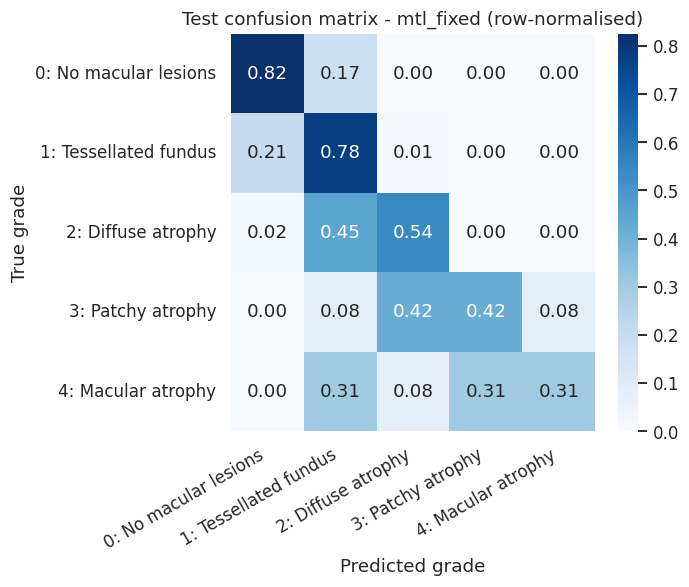

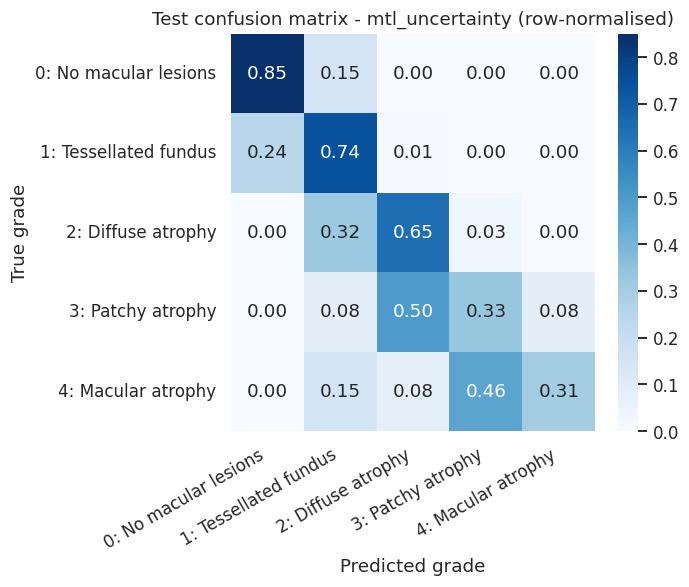

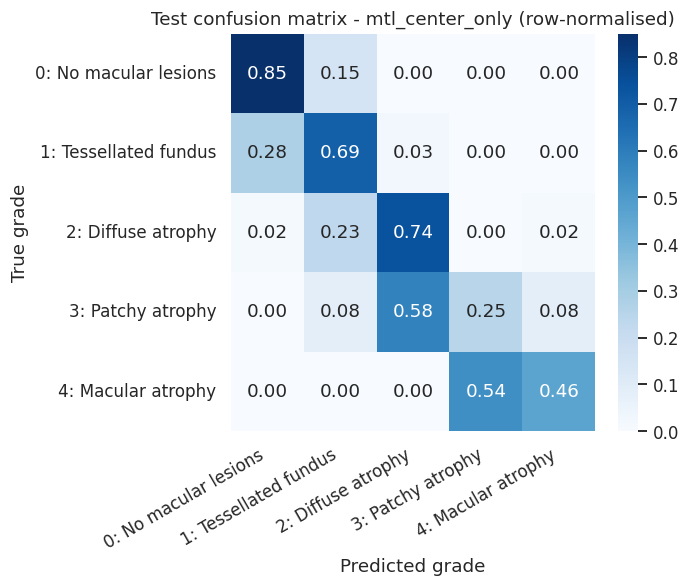

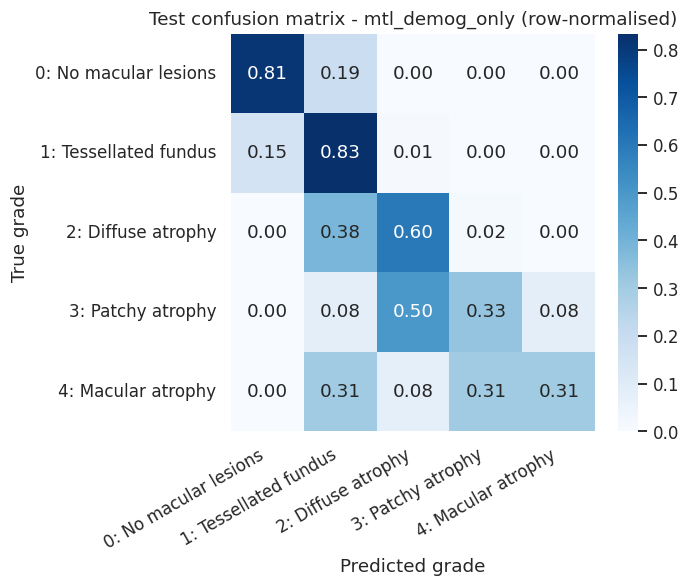

In [42]:
for name, out in outputs.items():
    cm = np.array(out["test_bundle"].confusion_matrix)
    fig = plot_confusion_matrix(
        cm, list(CLASS_NAMES), normalize=True,
        save_path=MTL_OUTPUT_DIR / f"{name}_cm_test.png",
        title=f"Test confusion matrix - {name}")
    plt.show()

In [ ]:
summary_rows: List[Dict[str, Any]] = [{
    "experiment": "baseline_resnet50",
    "kappa": base_bundle.quadratic_kappa,
    "kappa_ci": format_ci(base_ci["quadratic_kappa"]),
    "delta_vs_baseline": 0.0, "delta_ci": "-", "p_value": "-", "sig@5%": "-",
}]
# index paired_df by experiment so we can look up delta + CI + p per run
kappa_pairs = paired_df[paired_df["metric"] == "quadratic_kappa"].set_index("experiment")
for name, out in outputs.items():
    y, yp, pr = out["test_predictions"]
    ci = bootstrap_metrics(y, yp, pr, n_resamples=1000, seed=main_cfg.seed)
    rp = kappa_pairs.loc[name]
    dci = (f"[{rp['ci_low']:+.4f}, {rp['ci_high']:+.4f}]"
           if np.isfinite(rp["ci_low"]) and np.isfinite(rp["ci_high"]) else "n/a")
    summary_rows.append({
        "experiment": name,
        "kappa": out["test_bundle"].quadratic_kappa,
        "kappa_ci": format_ci(ci["quadratic_kappa"]),
        "delta_vs_baseline": float(rp["delta"]),
        "delta_ci": dci, "p_value": float(rp["p_value"]), "sig@5%": rp["sig@5%"],
    })
mtl_summary_df = pd.DataFrame(summary_rows)
mtl_summary_df.to_csv(MTL_OUTPUT_DIR / "mtl_summary_table.csv", index=False)
mtl_summary_df


,experiment,kappa,kappa_ci,delta_vs_baseline,delta_ci,p_value,sig@5%
0,baseline_resnet50,0.787645,"0.7876 [0.7139, 0.8537]",0.000000,-,-,-
1,mtl_fixed,0.772682,"0.7727 [0.7018, 0.8397]",-0.014963,"[-0.0337, +0.0026]",0.098,no
2,mtl_uncertainty,0.825676,"0.8257 [0.7647, 0.8740]",0.038031,"[-0.0030, +0.0903]",0.084,no
3,mtl_center_only,0.862222,"0.8622 [0.8291, 0.8937]",0.074577,"[+0.0217, +0.1392]",0.007,yes
4,mtl_demog_only,0.787871,"0.7879 [0.7149, 0.8512]",0.000226,"[-0.0362, +0.0354]",1.0,no
